In [9]:
import os
import skrf as rf
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter


In [3]:
def smooth_network(network, window=11, poly=3):
    """
    Smooth all S-parameters of a Network using Savitzky–Golay filter.
    Returns a new smoothed Network.
    """
    s = network.s.copy()
    n_freq, n_port, _ = s.shape

    s_smooth = np.zeros_like(s, dtype=complex)

    for i in range(n_port):
        for j in range(n_port):
            real_part = np.real(s[:, i, j])
            imag_part = np.imag(s[:, i, j])

            real_smooth = savgol_filter(real_part, window, poly)
            imag_smooth = savgol_filter(imag_part, window, poly)

            s_smooth[:, i, j] = real_smooth + 1j * imag_smooth

    smoothed_network = rf.Network(
        frequency=network.frequency,
        s=s_smooth,
        z0=network.z0
    )

    return smoothed_network


def load_directory(directory_path, window=30, poly=3):
    """
    Reads all .s2p files in a directory.
    Can Return two lists:
        {directory_name}_original
        {directory_name}_smoothed
    """

    directory_name = os.path.basename(os.path.normpath(directory_path))

    original_list = []
    smoothed_list = []

    for file in sorted(os.listdir(directory_path)):
        if file.lower().endswith(".s2p"):

            full_path = os.path.join(directory_path, file)

            # Load original network
            ntwk = rf.Network(full_path)

            # Use filename (without extension) as network name
            name = os.path.splitext(file)[0]
            ntwk.name = name

            original_list.append(ntwk)

            # Create smoothed version
            ntwk_smooth = smooth_network(ntwk, window, poly)
            ntwk_smooth.name = name

            smoothed_list.append(ntwk_smooth)

    # Dynamically create variable names
    globals()[f"{directory_name}_measured"] = original_list
    globals()[f"{directory_name}_smoothed"] = smoothed_list

    return original_list, smoothed_list

def avg_return_loss(ntwk):
    s11_db = ntwk.s_db[:,0,0]
    return np.mean(s11_db)
def worst_return_loss(ntwk):
    return np.max(ntwk.s_db[:640,0,0])   # closest to 0 dB
def avg_transmit_loss(ntwk):
    s11_db = ntwk.s_db[:,1,0]
    return np.mean(s11_db)
def worst_transmit_loss(ntwk):
    return np.max(ntwk.s_db[:,1,0])   # closest to 0 dB

In [4]:
set_04_measured, set_04_smoothed = load_directory(r'03_mar_meas_data(sample1)', window=11, poly=3)

In [5]:
set_04_smoothed
# ntwk.frequency

[2-Port Network: 'S11_Ecal_03-03-26',  25000000000.0-43500000000.0 Hz, 741 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'S12_Ecal_03-03-26',  25000000000.0-43500000000.0 Hz, 741 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'S21_Ecal_03-03-26',  25000000000.0-43500000000.0 Hz, 741 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'S22_Ecal_03-03-26',  25000000000.0-43500000000.0 Hz, 741 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'S_Parameter_CS-5_GSG_150P_CPW_20um_03-03-26',  25000000000.0-43500000000.0 Hz, 741 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'set_04_17_5',  25000000000.0-43500000000.0 Hz, 741 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'set_04_18_5',  25000000000.0-43500000000.0 Hz, 741 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'set_04_19_5',  25000000000.0-43500000000.0 Hz, 741 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'set_04_20_5',  25000000000.0-43500000000.0 Hz, 741 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'set_04_21_5',  25000000000.0-43500000000.0 Hz, 741 pts, z0=[50

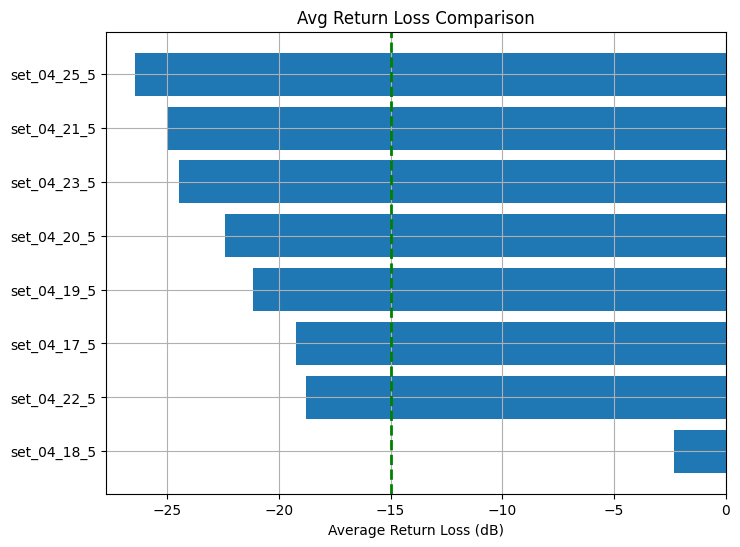

In [6]:
#average case refection comparison:
values = []
names = []
for ntwk in set_04_measured[5:]:   # skip the first 4 networks
    names.append(ntwk.name)
    values.append(avg_return_loss(ntwk))
sorted_data = sorted(zip(names, values), key=lambda x: x[1], reverse=True) #sorts the zipped tuple lists based on the first index of each tuple (the value)
sorted_names, sorted_values = zip(*sorted_data) #unzip the sorted data into separate lists
plt.figure(figsize=(8,6))
plt.barh(sorted_names, sorted_values)

plt.axvline(x=-15, color='g', linestyle='--', linewidth=2)
plt.grid()
plt.xlabel("Average Return Loss (dB)")
plt.title("Avg Return Loss Comparison")

# plt.gca().invert_yaxis()   # optional: best at bottom
plt.show()


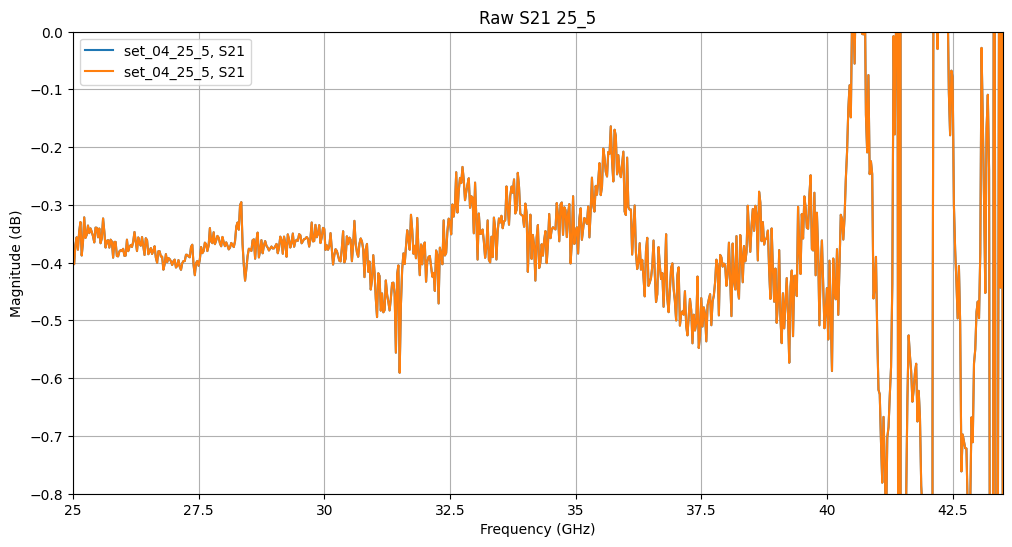

In [8]:
set_04_measured, set_04_smoothed = load_directory(r'03_mar_meas_data(sample1)', window=9, poly=3)

set_04_measured = set_04_measured[:6] + set_04_measured[7:]   # skip 18.5 iteration network
set_04_smoothed = set_04_smoothed[:6] + set_04_smoothed[7:]   # skip 18.5 iteration network

plt.figure(figsize=(12,6))
plt.title("Raw S21 25_5")
plt.grid()
set_04_measured[11].frequency.unit = 'GHz'
set_04_measured[11].plot_s_db(m=1,n=0)
set_04_measured[11].plot_s_db(m=1,n=0)
# for ntwk in set_04_measured[5:]:   # skip the first 4 networks
#     ntwk.frequency.unit = 'GHz'
#     ntwk.plot_s_db(m=0,n=0)
plt.ylim(-0.8, 0)
plt.savefig('Plotted_results_03_march/Raw S21 25_5', dpi=300, bbox_inches='tight') # Save the figure with high resolution and tight layout


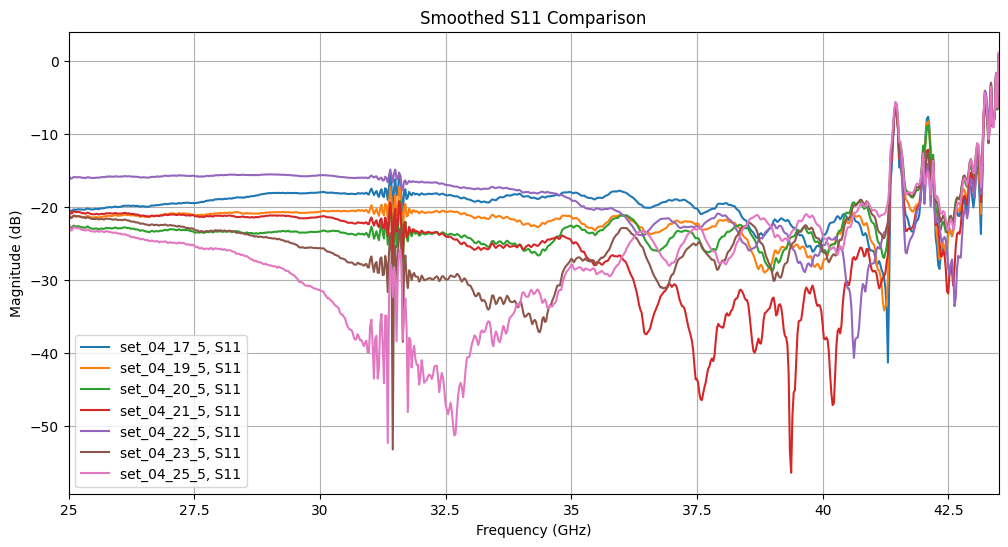

In [74]:
plt.figure(figsize=(12,6))
plt.title("Smoothed S11 Comparison")
plt.grid()
for ntwk in set_04_smoothed[5:]:   # skip the first 4 networks
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0)
plt.savefig('Plotted_results_03_march/Smoothed S11 Comparison', dpi=300, bbox_inches='tight') # Save the figure with high resolution and tight layout

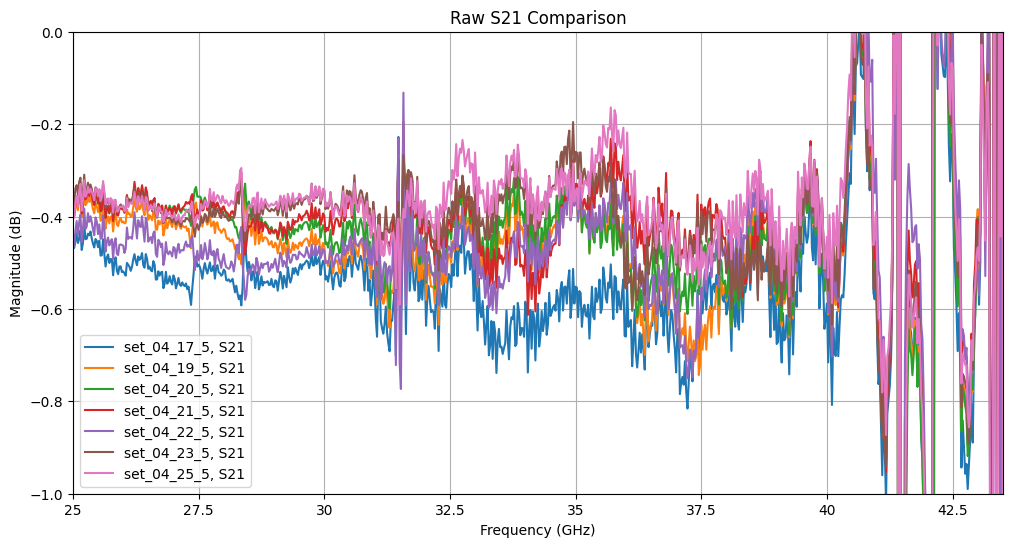

In [75]:
plt.figure(figsize=(12,6))
plt.title("Raw S21 Comparison")
plt.grid()
for ntwk in set_04_measured[5:]:   # skip the first 4 networks
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=1,n=0)
plt.ylim(-1, 0)
plt.savefig('Plotted_results_03_march/Raw S21 Comparison', dpi=300, bbox_inches='tight') # Save the figure with high resolution and tight layout

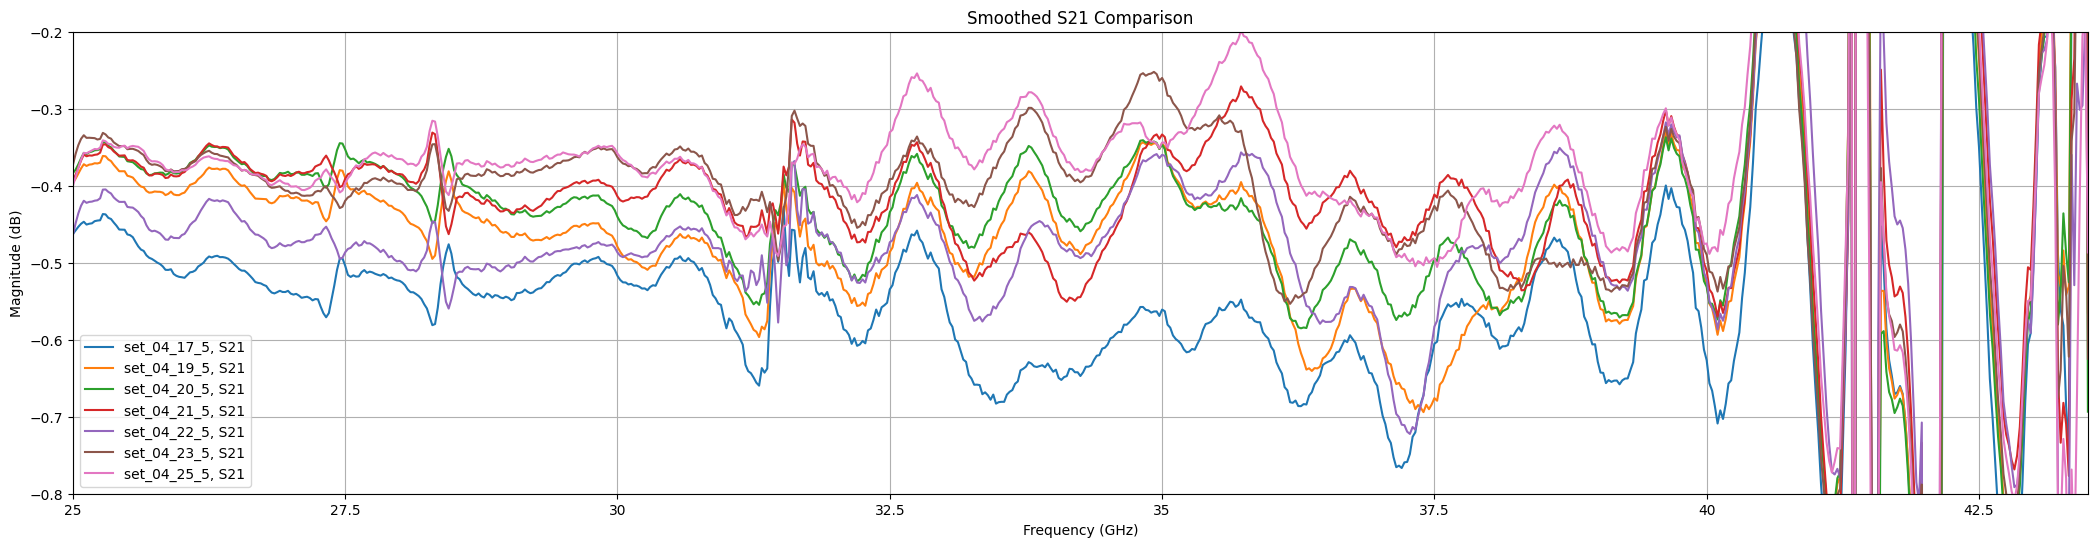

In [78]:
plt.figure(figsize=(26,6))
plt.title("Smoothed S21 Comparison")
plt.grid()
for ntwk in set_04_smoothed[5:]:   # skip the first 4 networks
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=1,n=0)
plt.ylim(-0.8, -0.2)
plt.savefig('Plotted_results_03_march/Smoothed S21 Comparison', dpi=300, bbox_inches='tight') # Save the figure with high resolution and tight layout